# Artificial Neural Networks — Classifying Handwritten Digits (MNIST)

In this notebook we build, train, and evaluate a **feedforward neural network** that recognises handwritten digits (0–9). We use the classic **MNIST** dataset: 70,000 grayscale images of 28×28 pixels, collected from US Census Bureau employees and high-school students.

MNIST is the "fruit fly" of machine learning: small enough to train in minutes, rich enough to illustrate every core concept — network architecture, loss functions, gradient-based training, overfitting, and honest evaluation.

**What you should take away:**

1. How an image becomes an input vector, and how a network of weights and biases turns it into a probability for each digit.
2. What actually happens during training (epochs, batches, gradient descent).
3. How to *read* a training log: what the comparison between **training** and **validation** performance tells us — and what it cannot tell us.
4. Why we keep a separate **test set** that we touch exactly once.

> **Note on the three-way data split.** We will divide the data into three parts with three distinct jobs: **training data** (the network learns its weights from these), **validation data** (never trained on; used to monitor generalisation *during* training and to choose settings like the number of epochs), and **test data** (never used for any decision; touched once at the very end to get an honest estimate of performance). Keep this distinction in mind throughout — it is the single most important discipline in applied machine learning.

## 1. Import libraries

Python itself knows nothing about neural networks. We import three specialist libraries:

- **TensorFlow / Keras** — TensorFlow is the numerical engine (it computes gradients and runs on GPUs); Keras is the friendly interface on top of it, in which we describe models layer by layer.
- **NumPy** — fast operations on arrays and matrices.
- **Matplotlib** — plotting.

We print the TensorFlow version because the Keras interface has changed across major versions; everything here assumes TF 2.x (which Colab provides).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the MNIST dataset

Keras ships with several classic datasets that download automatically. `mnist.load_data()` returns the data already split in two:

- `(x_train, y_train)` — **60,000** images the network will learn from;
- `(x_test, y_test)` — **10,000** images we lock away for the final evaluation.

Each `x` is a 28×28 array of pixel intensities (0 = black, 255 = white); each `y` is the integer label of the digit shown.

Why hold data back at all? Because the question we ultimately care about is not *"can the network reproduce the answers it was shown?"* but *"can it classify digits it has never seen?"* — the same reason an exam contains questions the students have not seen during the course. Performance on the training data alone can always be inflated by memorisation; only held-out data measures **generalisation**.

In [2]:
# Two tuples: 60,000 images to train on, 10,000 held back for the final test
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Shape notation: (number of samples, height, width)
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:    ", x_test.shape)
print("Label values (unique):", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape:     (10000, 28, 28)
Label values (unique): [0 1 2 3 4 5 6 7 8 9]


## 3. Look at the data first

Before modelling anything, look at the raw material. Two things to notice in the sample below:

- The digits vary considerably in slant, thickness, and style — this variation is exactly what the network must learn to see past.
- Some digits are genuinely ambiguous even to a human (a sloppy 4 can look like a 9, a 3 like a 5). This puts a **ceiling** on achievable accuracy: no classifier, however good, can be right about an image that does not contain enough information. Keep this in mind when we later celebrate ~98% accuracy — a large part of the remaining 2% is simply hard.

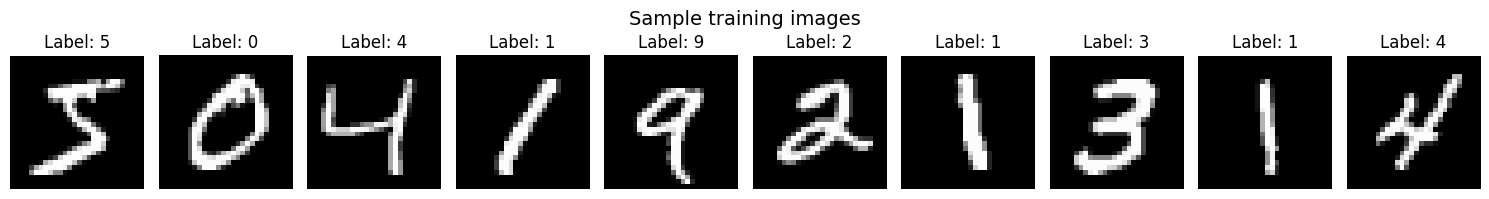

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.suptitle("Sample training images", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Pre-process the data

Two transformations before the images can enter the network:

**Normalise to [0, 1].** We divide every pixel by 255. Gradient-descent training behaves much better when inputs are small and on a common scale: with raw values up to 255, the weighted sums in the first layer would be huge, gradients would vary wildly in size, and the optimiser would need a much smaller learning rate to stay stable. (This is the same logic as standardising predictors in regression to make coefficients — here, weights — comparable and estimation well-behaved.)

**Flatten 28×28 → 784.** A dense (fully connected) layer takes a flat vector as input, so each image becomes a vector of 784 pixel values. Note what we give up: the network no longer knows that pixel 29 sits *directly below* pixel 1 — all spatial structure is discarded, and every pixel is just "input $x_j$". Convolutional networks (a later topic) are exactly the architecture that keeps and exploits the 2-D structure, which is why they beat dense networks on images.

In [4]:
# Normalise: pixel intensities 0-255 -> floats in [0, 1]
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Flatten: (n, 28, 28) -> (n, 784); -1 lets NumPy infer the first dimension
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

print("After flattening — training shape:", x_train.shape)
print("After flattening — test shape:    ", x_test.shape)

After flattening — training shape: (60000, 784)
After flattening — test shape:     (10000, 784)


## 5. Build the network

We stack layers with the Keras `Sequential` API:

| Layer | Size | Activation | Role |
|---|---|---|---|
| Input | 784 | — | one value per pixel |
| Hidden 1 | 128 | ReLU | learns low-level features |
| Hidden 2 | 64 | ReLU | combines them into higher-level features |
| Output | 10 | Softmax | one probability per digit |

**ReLU**, $f(z) = \max(0, z)$, is the non-linearity applied to each hidden neuron's weighted sum. Without it, a stack of linear layers would collapse into a single linear map — the depth would buy nothing. ReLU is the standard choice because it is cheap and its gradient does not vanish for positive inputs.

**Softmax** converts the 10 raw output scores into probabilities that are positive and sum to 1. If the scores are $z_1,\dots,z_{10}$, then $P(\text{digit}=k) = e^{z_k} / \sum_j e^{z_j}$. You have seen this before: it is exactly the **multinomial logit** link function — the output layer of this network *is* a multinomial logit model, whose "predictors" are the 64 learned features of the last hidden layer.

**Where do the parameter counts come from?** Every neuron has one weight per input plus one bias:

- Hidden 1: $784 \times 128 + 128 = 100{,}480$
- Hidden 2: $128 \times 64 + 64 = 8{,}256$
- Output: $64 \times 10 + 10 = 650$
- **Total: 109,386** — check this against `model.summary()` below.

These 109,386 numbers are what training will adjust. Note the ratio: ~109k parameters for 54k training images (after the validation split). The model has plenty of capacity — enough to memorise quirks of the training data. Remember that for Section 8.

*(The `UserWarning` about `input_shape` in the output is harmless — newer Keras prefers a separate `Input` layer, but both forms build the same model.)*

In [5]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),  # hidden layer 1
    keras.layers.Dense(64, activation='relu'),                       # hidden layer 2
    keras.layers.Dense(10, activation='softmax')                     # output layer
])

# Parameters = weights + biases; these are what the network learns
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile: choose loss and optimiser

Compiling specifies *what* to minimise and *how*:

- **Loss — `sparse_categorical_crossentropy`.** For each image, the loss is $-\log \hat{p}_{y}$: minus the log of the probability the model assigned to the *correct* digit. Minimising cross-entropy is therefore nothing more exotic than **maximum likelihood estimation** of the multinomial model in the output layer. A confident correct prediction ($\hat{p} \approx 1$) costs almost nothing; a confident *wrong* prediction is punished heavily — a property that will matter when we interpret the loss curves. ("Sparse" only means our labels are plain integers 0–9 rather than one-hot vectors.)

- **Optimiser — `adam`.** A refinement of stochastic gradient descent that adapts the step size per parameter using running averages of recent gradients. It is the default choice because it works well with almost no tuning.

- **Metric — `accuracy`.** The fraction of images classified correctly. We *report* accuracy because it is interpretable, but we *train* on cross-entropy because it is smooth and differentiable (accuracy, a step function, provides no gradient). The two can diverge — watch for this in Section 8.

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Train

`model.fit()` runs the training loop. The three knobs:

- **`batch_size=32`** — weights are updated after each mini-batch of 32 images, using the gradient of the loss on that batch. Small batches give noisy but frequent updates; the noise even helps escape poor solutions.
- **`epochs=10`** — ten full passes through the training data.
- **`validation_split=0.1`** — the last 10% of the training set (6,000 images) is set aside as **validation data**: the network never trains on these, but at the end of every epoch it is evaluated on them.

Arithmetic check: 54,000 training images ÷ 32 per batch = **1,688 weight updates per epoch** — exactly the `1688/1688` you see in the progress bar. Over 10 epochs the network adjusts its 109,386 parameters 16,880 times.

Each epoch line reports four numbers: `accuracy`/`loss` on the training data and `val_accuracy`/`val_loss` on the held-out validation data. The next section is about reading these two pairs against each other.

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,   # hold back 10% = 6,000 images for validation
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9246 - loss: 0.2591 - val_accuracy: 0.9660 - val_loss: 0.1119
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9674 - loss: 0.1078 - val_accuracy: 0.9733 - val_loss: 0.0923
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9781 - loss: 0.0738 - val_accuracy: 0.9783 - val_loss: 0.0771
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0558 - val_accuracy: 0.9767 - val_loss: 0.0800
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9859 - loss: 0.0432 - val_accuracy: 0.9800 - val_loss: 0.0734
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9890 - loss: 0.0346 - val_accuracy: 0.9782 - val_loss: 0.0810
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9898 - loss: 0.0303 - val_accuracy: 0.9748 - val_loss: 0.0927
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9916 - loss: 0.0258 - 

## 8. Reading the training history: what the training–validation comparison teaches us

The plots below show accuracy and loss per epoch, each with two curves: performance on the data the network **trains on**, and on the validation data it **only gets graded on**. This comparison is the single most informative diagnostic in deep learning. Four lessons, using the actual numbers from the run above:

**1. Early on, both curves improve together — the network is genuinely learning.** In epochs 1–3, training accuracy climbs from 92.7% to 97.7% *and* validation accuracy climbs from 96.7% to 97.7%. Improvements that show up on data the model has never trained on are real generalisation, not memorisation.

**2. Then the curves separate — that gap is overfitting.** From epoch 4 onwards, training accuracy keeps climbing to 99.3%, but validation accuracy stalls around 97.6–98.0%. The widening **generalisation gap** means the additional "learning" consists of memorising idiosyncrasies of the 54,000 training images — pixel quirks of particular examples — which does nothing for new data. The model is not getting *better at the task*; it is getting better at *its training set*.

**3. The loss curves show it even more clearly than accuracy.** Training loss falls monotonically (0.25 → 0.02), but validation loss bottoms out around epoch 3–6 (≈ 0.078) and then *rises* to 0.093. Note the subtlety: validation loss worsens while validation *accuracy* stays flat. How can that be? Cross-entropy punishes confident errors. The model still gets the same ~2.3% of validation images wrong, but with each extra epoch it becomes more *confident* in those wrong answers ($-\log \hat p$ explodes as the probability on the true class shrinks). Overfitting often announces itself in the loss before it shows in accuracy.

**4. The practical payoff: the comparison tells us when to stop and whether to regularise.** Everything after roughly epoch 5 cost computation and bought nothing — with 20 more epochs, training accuracy would reach ~100% while validation performance would drift *down*. Two standard responses:
   - **Early stopping**: monitor `val_loss` and keep the weights from its minimum (Keras: `keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)`).
   - **Regularisation**, e.g. **dropout**: randomly silence a fraction of hidden neurons at each training step so the network cannot rely on any single memorised pathway.

One thing this comparison does **not** give us: an estimate of final performance. We used the validation data to make decisions (how many epochs to run, which architecture to keep), so validation scores are subtly optimistic — models that look good on the validation set are partly models that got *lucky* on it. That is what the untouched test set is for, next.

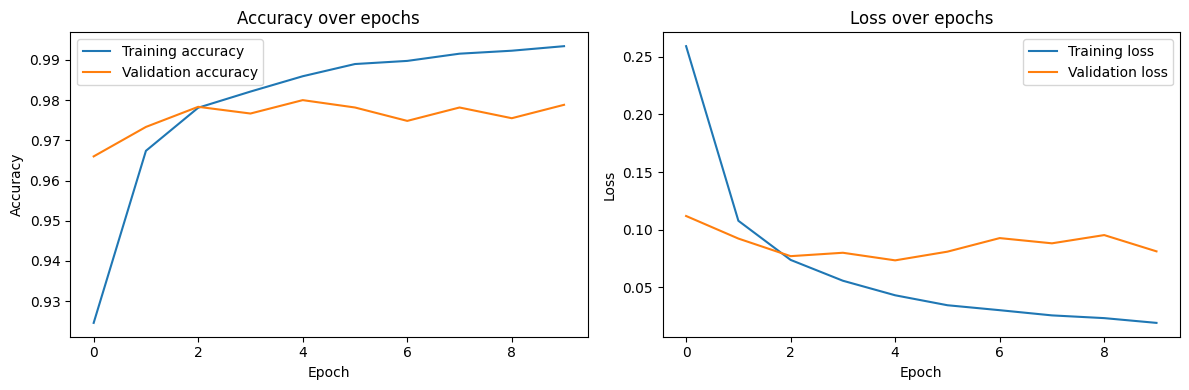

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over epochs')
ax1.legend()

ax2.plot(history.history['loss'],     label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over epochs')
ax2.legend()

plt.tight_layout()
plt.show()

The best epoch to stop is shown below.

In [22]:
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                   restore_best_weights=True, verbose=1)
print(es.stopped_epoch + 1)

1


## 9. The final exam: evaluate on the test set

Now — once, and only now — we open the vault with the 10,000 test images. The model has never seen them, and *we* have never used them to make any decision about the model. That second condition is what makes the test score honest: it measures the model, not our tuning.

The result, **97.63%**, sits right where the validation curve plateaued (~97.6–98%) — reassuring, because it confirms the validation estimate was not badly biased by our choices. In absolute terms: about 24 of every 1,000 unseen digits are misclassified.

If we now went back, tweaked the architecture, and re-evaluated on the test set repeatedly, the test set would silently turn into a second validation set and lose its honesty. In real projects the test set is evaluated once, at the end, full stop.

In [23]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_accuracy * 100:.2f} %")
print(f"Test loss:     {test_loss:.4f}")


Test accuracy: 97.96 %
Test loss:     0.0844


## 10. Inspect individual predictions

`model.predict()` returns, for each image, the 10 softmax probabilities; `np.argmax` picks the most probable digit as the prediction. Below we display ten test images with the true label, the predicted label, and the model's confidence.

Two things to look for:

- **The confidence numbers are typically very high (often > 99%).** Treat them with care: neural networks are notoriously **over-confident** — the softmax output is a probability in the mechanical sense, but it is not automatically well-*calibrated*. Among predictions made with "99% confidence", far more than 1% can be wrong, especially after overfitting (recall Section 8: extra epochs made the model more confident, not more correct).
- **When the model errs, is the error understandable?** Wrong predictions (in red, when they occur among these ten) usually involve genuinely awkward handwriting — often images you might misread yourself.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/tmp/ipykernel_2376/2186465919.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


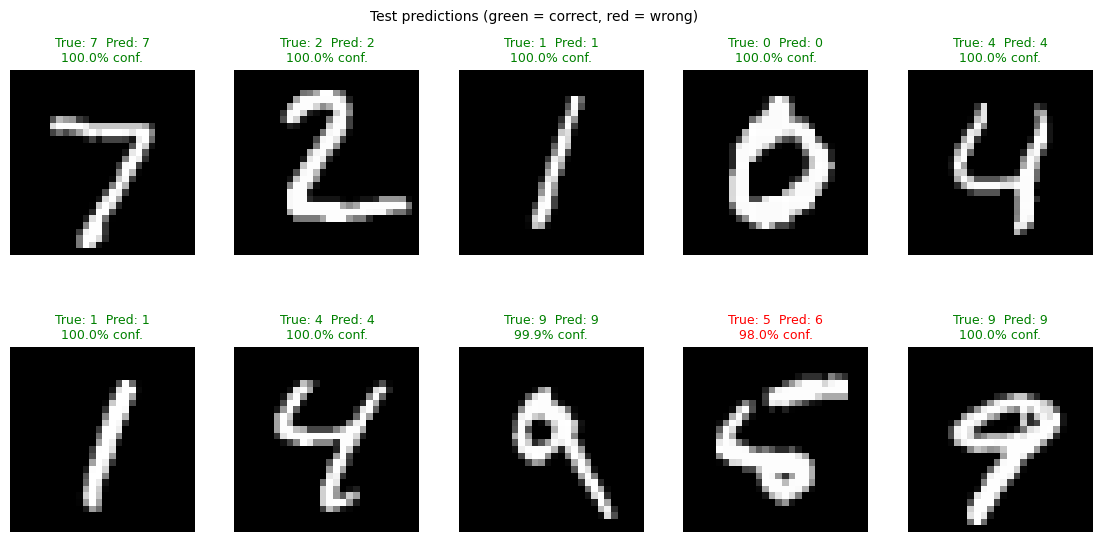

In [26]:
predictions = model.predict(x_test)                # shape: (10000, 10)
predicted_labels = np.argmax(predictions, axis=1)  # most probable digit per image

fig, axes = plt.subplots(2, 5, figsize=(14, 6),
                         gridspec_kw={'hspace': 0.5})  # increase to taste
axes = axes.flatten()

for i in range(10):
    image = x_test[i].reshape(28, 28)   # back to 28x28 for display
    axes[i].imshow(image, cmap='gray')

    true_label      = y_test[i]
    predicted_label = predicted_labels[i]
    confidence      = predictions[i][predicted_label] * 100

    colour = 'green' if predicted_label == true_label else 'red'
    axes[i].set_title(
        f"True: {true_label}  Pred: {predicted_label}\n{confidence:.1f}% conf.",
        color=colour, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Test predictions (green = correct, red = wrong)", fontsize=10)
plt.tight_layout()
plt.show()

## 11. Where do the errors live? The confusion matrix

Overall accuracy compresses 10,000 predictions into one number. The **confusion matrix** disaggregates it: rows are *true* digits, columns are *predicted* digits, so the diagonal holds correct classifications and every off-diagonal cell is a specific *kind* of mistake.

This matters because errors are not random — they are structured by visual similarity. In this run, for example, of the 892 test images of a **5**, the model called 865 correctly, and its most common mistake was calling them a **3** (10 times) — visually the closest digit. Expect similar neighbourhoods elsewhere: 4↔9, 7↔2, 8↔5.

Reading errors this way is far more instructive than the accuracy number: it tells you *what the model finds hard*, suggests where more data or a better architecture (e.g. one that sees spatial structure) would help, and connects directly to the ambiguous handwriting we noticed back in Section 3.

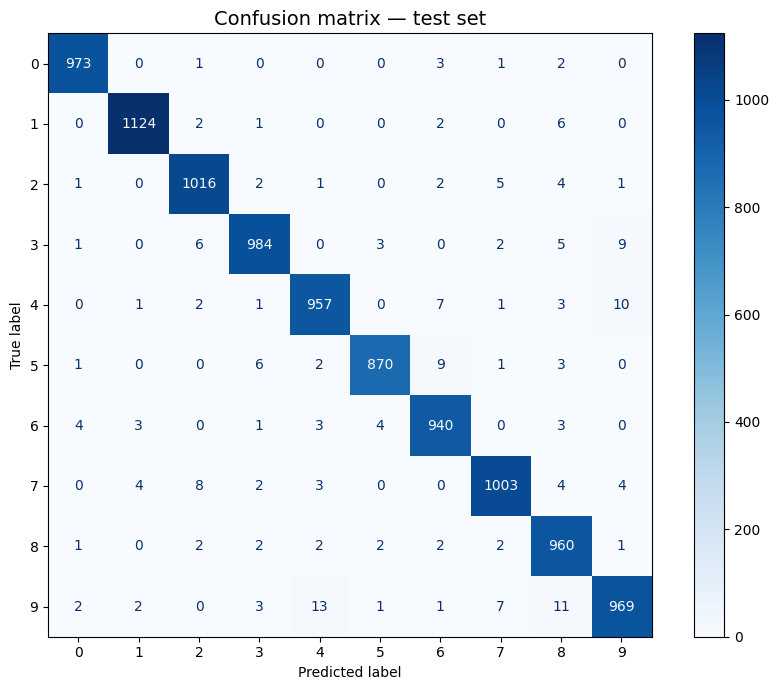


Row for digit 5 (true label = 5):
  Predicted 0: 1 times
  Predicted 3: 6 times
  Predicted 4: 2 times
  Predicted 5: 870 times
  Predicted 6: 9 times
  Predicted 7: 1 times
  Predicted 8: 3 times


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion matrix — test set", fontsize=14)
plt.tight_layout()
plt.show()

# Example read of one row: "of all images actually showing a 5,
# how often did the model predict each digit?"
print("\nRow for digit 5 (true label = 5):")
for digit, count in enumerate(cm[5]):
    if count > 0:
        print(f"  Predicted {digit}: {count} times")

## 12. Summary and things to try

**What we did:**

1. Loaded MNIST (60k training / 10k test images) and normalised + flattened the images.
2. Built a dense network 784 → 128 → 64 → 10 with 109,386 trainable parameters.
3. Trained for 10 epochs with Adam, holding out 6,000 validation images.
4. Diagnosed **mild overfitting** from the training–validation comparison: real learning for ~3–5 epochs, memorisation after that.
5. Measured an honest **97.63%** accuracy on the untouched test set, and located the remaining errors among visually similar digit pairs.

**Exercises — each connects to a diagnostic from this notebook:**

- **Provoke overfitting.** Train for 50 epochs. Predict what the four curves in Section 8 will do before you run it, then check.
- **Fight overfitting.** Add `keras.layers.Dropout(0.2)` after each hidden layer and retrain. The *training* accuracy should drop (the network is handicapped while learning) — what happens to *validation* accuracy, and to the gap?
- **Stop automatically.** Add `callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]` to `model.fit()` and see at which epoch training halts.
- **Vary capacity.** Try one hidden layer of 16 neurons (too little capacity?) and then 512 + 256 (too much?). Watch how the training–validation gap responds in each direction.
- **Change the optimiser.** Replace `'adam'` with `'sgd'`. How many epochs does it now take to reach 97% validation accuracy?